# jiuzhang-sdk 云平台完整调用与本地分析示例

本 Notebook 演示如何使用 `jiuzhang-sdk` 进行环境配置、量子计算任务提交、轮询获取结果、以及使用内置的 Jupyter 助手和数据分析工具包进行结果比对。

## 1. 服务与凭证配置

运行前请登录九章量子获取 API Key，并填入下方 `API_KEY` 变量中。
为了保障代码示例简洁，实验参数如 `project_id`、`quantum_computer_id`、`mt`、`pump_energy_nj` 会在一个配置单元中统一设置，并在后续方法调用中复用。


In [16]:
import os
from datetime import datetime

import jiuzhang

# Service and credential configuration.
# Keep the same runnable shape as local_test/jiuzhang_sdk_demo.ipynb.
BASE_URL = "https://cloud.jiuzhangqt.com/api/v1"
API_KEY = "PQ-e334a01485ca4dca8f83f19b84c8f592"


def mask_api_key(value):
    if len(value) >= 10:
        return value[:7] + "***" + value[-4:]
    return "***"


PROJECT_ID = "EXP-a4bbabb57c704f68"
QUANTUM_COMPUTER_ID = "PH_QC_04"

MT_VALUE = 500
PUMP_ENERGY_NJ = 4.6
SQUEEZING_PARAM = 0.35
POLL_INTERVAL = 3.0
POLL_TIMEOUT = 1800.0
TASK_NAME = f"sdk-usage-{datetime.now():%Y%m%d_%H%M%S}"

# Jupyter helpers read configuration from environment variables.
os.environ["JIUZHANG_BASE_URL"] = BASE_URL
if not API_KEY:
    raise ValueError("API_KEY cannot be empty")
os.environ["JIUZHANG_API_KEY"] = API_KEY
os.environ["JIUZHANG_PROJECT_ID"] = PROJECT_ID
os.environ["JIUZHANG_QUANTUM_COMPUTER_ID"] = QUANTUM_COMPUTER_ID
os.environ["JIUZHANG_REQUEST_TIMEOUT"] = "30"
os.environ["JIUZHANG_POLL_INTERVAL"] = str(POLL_INTERVAL)

print("jiuzhang-sdk version:", jiuzhang.__version__)
print("API_KEY masked:", mask_api_key(API_KEY))
print("BASE_URL:", BASE_URL)
print("PROJECT_ID:", PROJECT_ID)
print("QUANTUM_COMPUTER_ID:", QUANTUM_COMPUTER_ID)
print("TASK_NAME:", TASK_NAME)


jiuzhang-sdk version: 0.1.0a30
API_KEY masked: PQ-e334***f592
BASE_URL: https://cloud.jiuzhangqt.com/api/v1
PROJECT_ID: EXP-a4bbabb57c704f68
QUANTUM_COMPUTER_ID: PH_QC_04
TASK_NAME: sdk-usage-20260723_172832


## 2. 检查 SDK 环境

使用 SDK 内置 Jupyter 助手展示当前环境配置（API Key 将被自动遮蔽以确保安全性）：

In [17]:
from jiuzhang.jupyter import show_environment

show_environment()


{'base_url': 'https://cloud.jiuzhangqt.com/api/v1',
 'api_key': 'PQ-e334***f592',
 'project_id': 'EXP-a4bbabb57c704f68',
 'quantum_computer_id': 'PH_QC_04',
 'request_timeout': '30.0',
 'poll_interval': '3.0'}

## 3. 初始化 SDK 客户端

In [18]:
from jiuzhang import CloudClient

client = CloudClient(base_url=BASE_URL, api_key=API_KEY, timeout=30)

print("SDK client initialized")


SDK client initialized


In [19]:
# Option 2: initialize from notebook environment variables.
from jiuzhang.jupyter import get_notebook_client

client_notebook = get_notebook_client()
print("Jupyter Notebook helper client initialized:", client_notebook)
client_notebook.close()


Jupyter Notebook helper client initialized: <jiuzhang.cloud.client.CloudClient object at 0x00000254E13E1430>


## 4. 构造实验参数并执行复杂度预估

In [20]:
from jiuzhang import GBSParams

# Current SDK uses quantum_computer_id as the field name; the value is the platform device code.
params = GBSParams(
    project_id=PROJECT_ID,
    task_name=TASK_NAME,
    quantum_computer_id=QUANTUM_COMPUTER_ID,
    mt=MT_VALUE,
    pump_energy_nj=PUMP_ENERGY_NJ,
    squeezing_param=SQUEEZING_PARAM,
)

print("Payload to send to cloud:")
print(params.to_cloud_payload())


Payload to send to cloud:
{'project_id': 'EXP-a4bbabb57c704f68', 'task_name': 'sdk-usage-20260723_172832', 'quantum_computer_id': 'PH_QC_04', 'mt_value': 500, 'pump_energy_nj': 4.6, 'squeezing_param': 0.35}


In [21]:
# Estimate complexity before submitting the task.
print("API_KEY masked:", mask_api_key(API_KEY))
estimate = client.estimate_runtime(
    quantum_computer_id=QUANTUM_COMPUTER_ID,
    mt_value=MT_VALUE,
    pump_energy_nj=PUMP_ENERGY_NJ,
)

print("Complexity estimate:")
print(estimate)


API_KEY masked: PQ-e334***f592
Complexity estimate:
{'code': 0, 'message': 'success', 'timestamp': '2026-07-23T09:28:33Z', 'data': {'classical_cost_time_s': 5.043057824372178e+17, 'classical_cost_time_us': 9223372036854775807, 'tianyan_response': {'classicalCostTime': 504305782437217800, 'estimatedChi': 3285061922895.4614, 'neff': 27.640263072852687, 'plotData': {'contourCurves': [{'points': [[1, 467817.1682178177], [1.0114960027371647, 466886.15472389944], [1.0231241635532624, 465946.32318552776], [1.0348860017379302, 464997.61193479307], [1.0467830540465628, 464039.95938568324], [1.0588168749010998, 463073.30404923507], [1.0709890365931192, 462097.58454906143], [1.0833011294892672, 461112.73963726114], [1.0957547622390493, 460118.70821071527], [1.1083515619850108, 459115.42932777625], [1.1210931745753314, 458102.84222535405], [1.133981264778866, 457080.88633640565], [1.1470175165026575, 456049.50130783225], [1.1602036330119478, 455008.6270187896], [1.173541337152722, 453958.203599416

## 5. 提交任务、轮询结果并解析 `GBSResult`

本节只提交一次真实云平台任务，并轮询到 `SUCCESS` / `FAILED` 等终态，然后把最终响应解析为 `GBSResult`。后续展示和画图都复用这里得到的 `result_raw` 与 `result`，避免整本 Notebook 执行时重复提交真实任务。


In [22]:
# Submit a cloud GBS task manually.
task = client.submit_task(
    project_id=PROJECT_ID,
    task_name=TASK_NAME,
    quantum_computer_id=QUANTUM_COMPUTER_ID,
    mt_value=MT_VALUE,
    pump_energy_nj=PUMP_ENERGY_NJ,
    squeezing_param=SQUEEZING_PARAM,
)

task_id = task["data"]["task_id"]
print("Task ID:", task_id)


Task ID: jz_tsk_2ab50081de244061


In [23]:
# Poll the cloud task until it reaches a terminal status, then parse it into GBSResult.
import time

from jiuzhang import parse_gbs_result

TERMINAL_STATUSES = {"SUCCESS", "FAILED", "CANCELLED", "CANCELED", "2", "3"}


def extract_task_status(payload):
    data = payload.get("data", payload) if isinstance(payload, dict) else {}
    if not isinstance(data, dict):
        return None
    tianyan_response = data.get("tianyan_response")
    if isinstance(tianyan_response, dict) and tianyan_response.get("taskStatus") is not None:
        return str(tianyan_response.get("taskStatus"))
    if data.get("status") is not None:
        return str(data.get("status"))
    return None


def is_terminal_status(status):
    status_text = str(status or "").upper()
    return status_text in TERMINAL_STATUSES


def poll_task_until_terminal(task_id, *, poll_interval=POLL_INTERVAL, timeout=POLL_TIMEOUT):
    deadline = time.monotonic() + timeout
    attempt = 0
    last_payload = None
    while time.monotonic() <= deadline:
        attempt += 1
        last_payload = client.get_result(task_id)
        status = extract_task_status(last_payload)
        print(f"poll #{attempt}: status={status}")
        if is_terminal_status(status):
            return last_payload
        time.sleep(poll_interval)
    raise TimeoutError(f"Task {task_id} did not finish within {timeout} seconds")


result_raw = poll_task_until_terminal(task_id)
result = parse_gbs_result(result_raw)

print("GBSResult status:", result.status_name)
print("GBSResult task_id:", result.task_id)
print("resultMapPoints curves:", sorted(result.result_map_points))


poll #1: status=INIT
poll #2: status=2
GBSResult status: SUCCESS
GBSResult task_id: jz_tsk_2ab50081de244061
resultMapPoints curves: ['distinguishable', 'experimental', 'ground_truth', 'squashed', 'thermal']


## 6. 可选：一键运行 `run_gbs`

`run_gbs` 会在一次调用中完成参数校验、复杂度预估、任务提交、轮询等待和结果解析。为避免整本 Notebook 执行时再次提交真实云平台任务，下方单元默认不执行一键提交；需要单独验证一键接口时，将 `RUN_ONE_SHOT_DEMO = True` 后只运行本单元即可。


In [24]:
# 可选的一键运行：返回解析后的 GBSResult 对象。
RUN_ONE_SHOT_DEMO = False

if RUN_ONE_SHOT_DEMO:
    result = client.run_gbs(params, poll_interval=POLL_INTERVAL, timeout=POLL_TIMEOUT)
    print("已执行一键 run_gbs。")
else:
    print("跳过一键 run_gbs，避免重复提交第二个真实云平台任务。")
    print("复用第 5 节解析得到的 GBSResult。")

print("GBSResult status:", result.status_name)
print("GBSResult task_id:", result.task_id)


跳过一键 run_gbs，避免重复提交第二个真实云平台任务。
复用第 5 节解析得到的 GBSResult。
GBSResult status: SUCCESS
GBSResult task_id: jz_tsk_2ab50081de244061


## 7. 渲染结果展示

在 Notebook 中，我们可以使用 `display_gbs_result` 辅助方法将 `GBSResult` 以漂亮的表格样式展现出来：

In [25]:
from jiuzhang.jupyter import display_gbs_result

# 自动在 IPython 界面生成可视化 HTML 表格，并返回摘要
display_gbs_result(result)


task_id,jz_tsk_2ab50081de244061
status,SUCCESS
task_name,sdk-usage-20260723_172832
quantum_computer_id,None
mt,500
sample_count,9675867
download_url,https://jiangsu-10.zos.ctyun.cn/qccp2/lightQuantumSupremacy/example/S64%282nJ%29.zip
result_map_points,"['distinguishable', 'experimental', 'ground_truth', 'squashed', 'thermal']"


{'task_id': 'jz_tsk_2ab50081de244061',
 'status': 'SUCCESS',
 'task_name': 'sdk-usage-20260723_172832',
 'quantum_computer_id': None,
 'mt': 500,
 'sample_count': 9675867,
 'download_url': 'https://jiangsu-10.zos.ctyun.cn/qccp2/lightQuantumSupremacy/example/S64%282nJ%29.zip',
 'result_map_points': ['distinguishable',
  'experimental',
  'ground_truth',
  'squashed',
  'thermal']}

## 8. 可视化 `resultMapPoints`

云平台结果中的 `resultMapPoints` 包含实验采样、理论基准和多种模型曲线。下面直接使用 `GBSResult.result_map_points` 绘制概率分布曲线、模型偏差、累计分布以及部分任务元数据。


In [26]:
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager

CURVE_LABELS = {
    "experimental": "实验数据",
    "ground_truth": "理论基准",
    "squashed": "压缩态模型",
    "thermal": "热态模型",
    "distinguishable": "可区分光子模型",
}

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC"]:
    if font_name in available_fonts:
        plt.rcParams["font.sans-serif"] = [font_name]
        break
plt.rcParams["axes.unicode_minus"] = False


def normalize_curve_points(result_map_points: dict[str, Any] | None) -> dict[str, np.ndarray]:
    """将 resultMapPoints 归一化为按光子数排序的 numpy 数组。"""
    normalized: dict[str, np.ndarray] = {}
    for name, points in (result_map_points or {}).items():
        arr = np.asarray(points, dtype=float)
        if arr.ndim != 2 or arr.shape[1] < 2 or arr.size == 0:
            continue
        arr = arr[:, :2]
        arr = arr[np.argsort(arr[:, 0])]
        normalized[name] = arr
    if not normalized:
        raise ValueError("GBSResult 中没有有效的 resultMapPoints 曲线。")
    return normalized


curves: dict[str, np.ndarray] = normalize_curve_points(result.result_map_points)
print("可用曲线:", list(curves))


可用曲线: ['experimental', 'ground_truth', 'squashed', 'thermal', 'distinguishable']


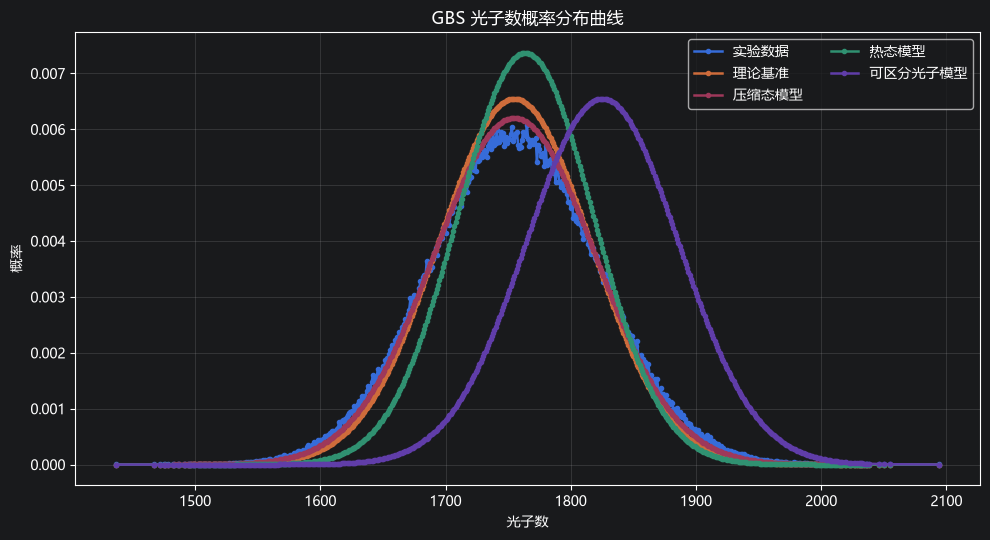

In [27]:
# 绘制云平台返回的全部概率分布曲线。
fig, ax = plt.subplots(figsize=(10, 5.5))
for name, arr in curves.items():
    ax.plot(
        arr[:, 0],
        arr[:, 1],
        marker="o",
        markersize=3,
        linewidth=1.8,
        label=CURVE_LABELS.get(name, name),
    )

ax.set_title("GBS 光子数概率分布曲线")
ax.set_xlabel("光子数")
ax.set_ylabel("概率")
ax.grid(True, alpha=0.25)
ax.legend(ncol=2)
fig.tight_layout()
plt.show()


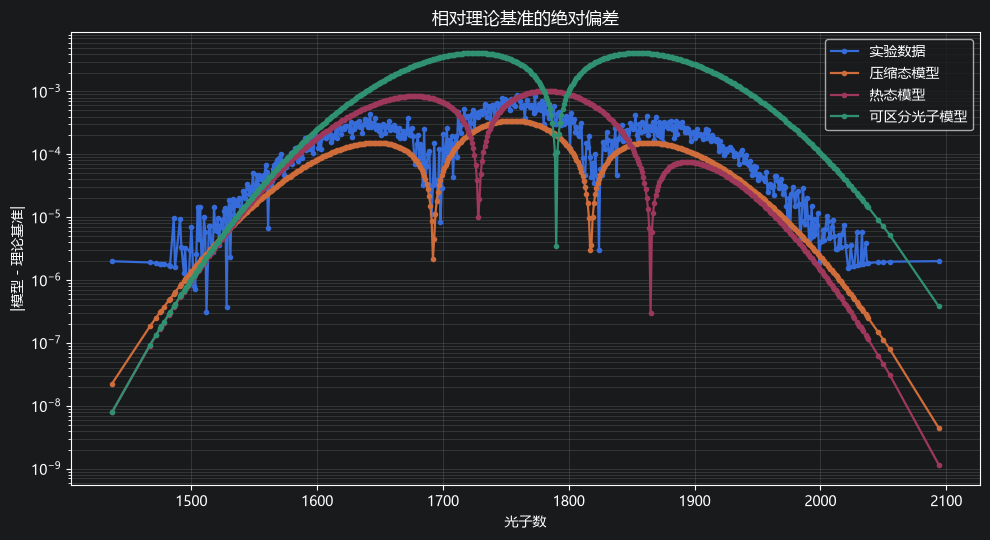

In [28]:
# 对比各模型曲线与理论基准曲线的绝对偏差。
ground_truth = curves.get("ground_truth")
if ground_truth is None:
    print("未返回 ground_truth 曲线，跳过偏差图。")
else:
    ground_truth_points: np.ndarray = ground_truth
    ground_truth_by_x: dict[float, float] = {
        float(x): float(y) for x, y in ground_truth_points.tolist()
    }
    fig, ax = plt.subplots(figsize=(10, 5.5))
    for name in ["experimental", "squashed", "thermal", "distinguishable"]:
        model_curve = curves.get(name)
        if model_curve is None:
            continue
        model_points: np.ndarray = model_curve
        common = [
            (float(x), float(y), ground_truth_by_x[float(x)])
            for x, y in model_points.tolist()
            if float(x) in ground_truth_by_x
        ]
        if not common:
            continue
        xs = np.asarray([item[0] for item in common])
        deltas = np.asarray([abs(item[1] - item[2]) for item in common])
        ax.plot(xs, deltas, marker="o", markersize=3, linewidth=1.6, label=CURVE_LABELS.get(name, name))

    ax.set_title("相对理论基准的绝对偏差")
    ax.set_xlabel("光子数")
    ax.set_ylabel("|模型 - 理论基准|")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.25, which="both")
    ax.legend()
    fig.tight_layout()
    plt.show()


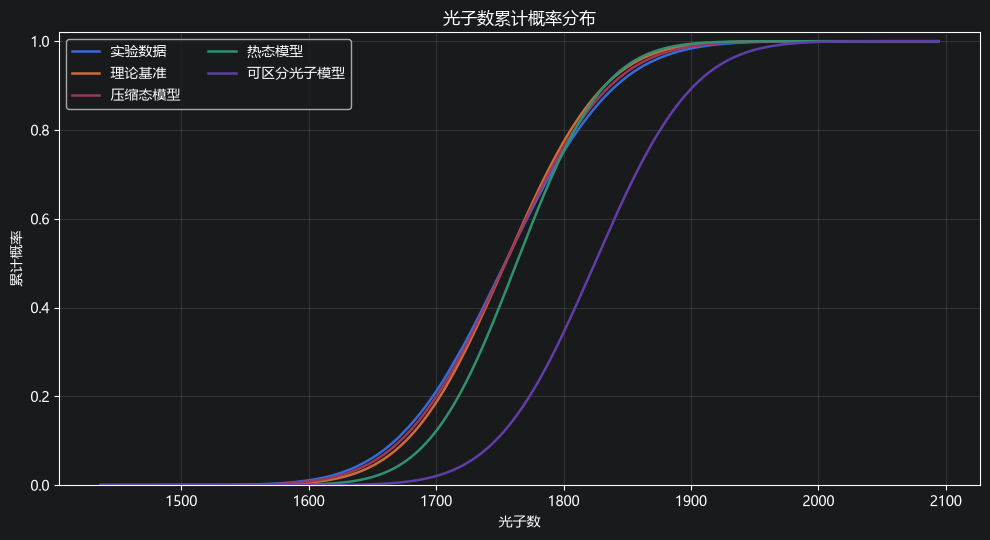

In [29]:
# 绘制累计分布，用于比较不同曲线的概率质量集中程度。
fig, ax = plt.subplots(figsize=(10, 5.5))
for name, arr in curves.items():
    probabilities = arr[:, 1]
    total = float(probabilities.sum())
    if total <= 0:
        continue
    ax.plot(
        arr[:, 0],
        np.cumsum(probabilities) / total,
        linewidth=1.8,
        label=CURVE_LABELS.get(name, name),
    )

ax.set_title("光子数累计概率分布")
ax.set_xlabel("光子数")
ax.set_ylabel("累计概率")
ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.25)
ax.legend(ncol=2)
fig.tight_layout()
plt.show()


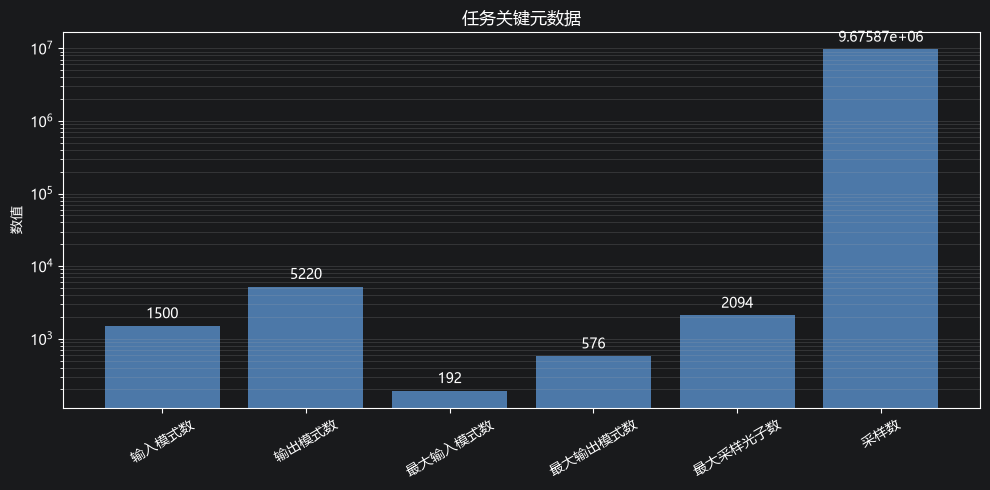

In [30]:
# 可视化云平台/天衍响应中的部分任务元数据。
def extract_tianyan_response(raw_payload):
    data = raw_payload.get("data", raw_payload) if isinstance(raw_payload, dict) else {}
    return data.get("tianyan_response", data) if isinstance(data, dict) else {}


metadata = extract_tianyan_response(result_raw)
summary_fields = {
    "输入模式数": "inputModeCount",
    "输出模式数": "outputModeCount",
    "最大输入模式数": "maxInputModeCount",
    "最大输出模式数": "maxOutputModeCount",
    "最大采样光子数": "maxSamplePhotonCount",
    "采样数": "sampleCount",
}

summary = {}
for label, key in summary_fields.items():
    value = metadata.get(key)
    if isinstance(value, bool) or value is None:
        continue
    try:
        summary[label] = float(value)
    except (TypeError, ValueError):
        pass

if not summary:
    print("未返回可绘制的数值型任务元数据，跳过元数据图。")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    labels = list(summary)
    values = [summary[label] for label in labels]
    bars = ax.bar(labels, values, color="#4c78a8")
    ax.set_title("任务关键元数据")
    ax.set_ylabel("数值")
    ax.set_yscale("log")
    ax.grid(True, axis="y", alpha=0.25, which="both")
    ax.tick_params(axis="x", rotation=30)
    ax.bar_label(bars, labels=[f"{value:g}" for value in values], padding=3)
    fig.tight_layout()
    plt.show()


## 9. 本地分布分析与拟合比对

SDK 内置了轻量级的局部数据分析库，可对量子实验结果数据和理论基准进行比对（如计算全变分距离、Hellinger 距离与 JS 散度）：

In [31]:
from jiuzhang.gbs.analysis import total_variation_distance, hellinger_distance, js_divergence

# Mock/platform results are point pairs [[x, y], ...]; analysis helpers expect distributions.
def to_dist(points):
    if not points:
        return {}
    return {str(item[0]): float(item[1]) for item in points}

p = to_dist(result.experimental_distribution)
q = to_dist(result.ground_truth_distribution)

if p and q:
    tvd = total_variation_distance(p, q)
    hd = hellinger_distance(p, q)
    js = js_divergence(p, q)
    print(f"Total variation distance (TVD): {tvd:.6f}")
    print(f"Hellinger distance (HD)       : {hd:.6f}")
    print(f"JS divergence (JSD)           : {js:.6f}")
else:
    print("No experimental or baseline distribution points available.")


Total variation distance (TVD): 0.051730
Hellinger distance (HD)       : 0.053796
JS divergence (JSD)           : 0.002871


## 10. 释放资源

In [32]:
# 释放 HTTP 客户端底层连接池资源
client.close()
print("SDK client closed successfully.")

SDK client closed successfully.
